# Analysis of MDA-MB-231 Morphology Data

Quantifying cell and nuclear area and nuclear to cytoplasmic ratio.

- Use environment.yml

# Imports

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Optional, Dict

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Functions

In [2]:
def extract_measurement_by_sample(
    folder_path: str,
    measurement_col: str,
    file_glob: str = "*.csv",
    sample_token_index: int = 2,     # 0-based: token after 2nd underscore => index 2
    enforce_equal_length: bool = False,
) -> pd.DataFrame:
    """
    Build a wide dataframe where each column is a sample name extracted from the filename
    (token at `sample_token_index` after splitting on '_'), and values are taken from
    `measurement_col` in that CSV.

    Example filename:
      cell_morphology_Fusion_etc.csv  -> sample 'Fusion' (index 2)

    Parameters
    ----------
    folder_path : str | Path
        Folder containing sample CSVs.
    measurement_col : str
        Column to extract from each CSV (e.g., 'area_um2').
    file_glob : str
        Pattern for selecting files (default '*.csv').
    sample_token_index : int
        Which underscore-split token contains sample name (default 2).
    enforce_equal_length : bool
        If True, raise if sample columns have different lengths.
        If False, pad shorter columns with NaN (default).

    Returns
    -------
    pd.DataFrame
        Wide dataframe: one column per sample.
    """
    folder = Path(folder_path)
    if not folder.exists() or not folder.is_dir():
        raise FileNotFoundError(f"Folder not found or not a directory: {folder}")

    files = sorted(folder.glob(file_glob))
    if not files:
        raise FileNotFoundError(f"No files matched pattern '{file_glob}' in {folder}")

    series_dict: dict[str, pd.Series] = {}
    lengths = set()

    for fp in files:
        # sample name is token after 2nd underscore
        tokens = fp.stem.split("_")
        if len(tokens) <= sample_token_index:
            raise ValueError(
                f"Filename '{fp.name}' does not have enough '_' tokens to extract sample "
                f"(need index {sample_token_index})."
            )
        sample_name = tokens[sample_token_index]

        df = pd.read_csv(fp)

        if measurement_col not in df.columns:
            raise KeyError(
                f"Column '{measurement_col}' not found in '{fp.name}'. "
                f"Columns: {list(df.columns)}"
            )

        s = df[measurement_col].reset_index(drop=True)
        series_dict[sample_name] = s
        lengths.add(len(s))

    if enforce_equal_length and len(lengths) > 1:
        raise ValueError(f"Not all files have the same number of rows: {sorted(lengths)}")

    # Combine; pandas will align by index and pad with NaN where needed
    out = pd.DataFrame(series_dict)

    # Optional: deterministic column order (alphabetical by sample name)
    out = out.reindex(sorted(out.columns), axis=1)

    return out


In [3]:
def summarize_samples_to_groups(
    df_wide: pd.DataFrame,
    *,
    group_cols: tuple[str, str, str] = ("Fusion", "Control", "Parental"),
    enforce_known_samples: bool = False,
    custom_group_map: Optional[Dict[str, str]] = None,
) -> pd.DataFrame:
    """
    Summarize each sample column in df_wide to its mean, then place that mean into a group column.

    Default grouping rules (unless overridden by custom_group_map):
      - Sample names starting with 'F' -> Fusion (e.g., F1..F8)
      - Sample names starting with 'C' -> Control (e.g., C1..C8)
      - Sample names starting with 'GFP' or 'MC' OR exactly 'GFP'/'MC' -> Parental

    Parameters
    ----------
    df_wide : pd.DataFrame
        Wide dataframe: each column is a sample and contains replicate/object measurements.
    group_cols : tuple[str, str, str]
        Column names for (Fusion, Control, Parental) in the output.
    enforce_known_samples : bool
        If True, raise an error if any sample name cannot be assigned to a group.
        If False, unknown samples are included as rows with all-NaN group values.
    custom_group_map : dict[str, str] | None
        Optional explicit mapping of sample_name -> group name (must match one of group_cols).
        If provided, it takes precedence over the default rules for any sample in the dict.

    Returns
    -------
    pd.DataFrame
        Index: sample names (from df_wide.columns)
        Columns: group_cols (Fusion/Control/Parental by default)
        Values: per-sample mean in the correct group column; others NaN.
    """
    if df_wide is None or df_wide.shape[1] == 0:
        raise ValueError("df_wide must have at least one sample column.")

    # Convert values to numeric safely (coerce non-numeric to NaN)
    df_num = df_wide.apply(pd.to_numeric, errors="coerce")

    fusion_col, control_col, parental_col = group_cols

    def infer_group(sample_name: str) -> Optional[str]:
        # Custom overrides first (if provided)
        if custom_group_map and sample_name in custom_group_map:
            return custom_group_map[sample_name]

        s = str(sample_name).strip()

        # Default rules
        if s.startswith("F"):
            return fusion_col
        if s.startswith("C"):
            return control_col
        if s == "GFP" or s == "MC" or s.startswith("GFP") or s.startswith("MC"):
            return parental_col

        return None

    # Build output: one row per sample, with mean placed under the correct group column
    out = pd.DataFrame(index=df_num.columns, columns=list(group_cols), dtype=float)

    unknown = []
    for sample in df_num.columns:
        group = infer_group(sample)
        mean_val = float(np.nanmean(df_num[sample].values))

        if group is None:
            unknown.append(sample)
            # Leave as all-NaN row unless enforce_known_samples=True
        else:
            if group not in out.columns:
                raise ValueError(
                    f"Group '{group}' for sample '{sample}' is not in output columns {list(out.columns)}."
                )
            out.loc[sample, group] = mean_val

    if enforce_known_samples and unknown:
        raise ValueError(
            "Could not assign the following samples to a group: "
            + ", ".join(map(str, unknown))
            + ". Provide custom_group_map or rename samples."
        )

    # uncomment for alphabetical output of samples:
    # out = out.sort_index()

    return out

In [4]:
def stats_and_plot(dataframe, alpha=0.05, xlabel=None, ylabel=None, title=None, sig_bars=True, point_label=False, fig_size=(6, 6), font_sz=12, save_svg=False):
    """
    Perform t-tests between data in each column of the DataFrame
    and create a box and whisker plot with indicators for statistical significance.

    Parameters:
    dataframe (pd.DataFrame): The input DataFrame.
    alpha (float, optional): The significance level for the t-tests. Default is 0.05.
    save_svg (bool): If True, saves the plot as an SVG file using the title as the filename.

    Returns:
    pd.DataFrame: A DataFrame containing the p-values between each pair of columns.
    """
    import matplotlib as mpl
    from scipy.stats import shapiro, levene, mannwhitneyu, ttest_ind, kruskal
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    from scipy.stats import f_oneway, tukey_hsd
    import scikit_posthocs as sp
    import pingouin as pg

    dataframe = dataframe.apply(pd.to_numeric, errors='coerce')
    num_samples = dataframe.shape[1]
    p_values_df = pd.DataFrame(columns=dataframe.columns, index=dataframe.columns)

    fig, ax = plt.subplots(figsize=fig_size)

    # --- Clean spine styling ---
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')

    # --- Boxplot ---
    bp = ax.boxplot(
        [dataframe[col].dropna() for col in dataframe.columns],
        labels=dataframe.columns,
        showmeans=True,
        showfliers=False,
        patch_artist=True,
        meanprops=dict(marker='D', markerfacecolor='black', markeredgecolor='black', markersize=5),
        medianprops=dict(color='black', linewidth=2),
        boxprops=dict(facecolor='white', color='black', linewidth=1.5),
        whiskerprops=dict(color='black', linewidth=1.5, linestyle='--'),
        capprops=dict(color='black', linewidth=1.5),
    )

    # --- Jittered data points ---
    for i, col in enumerate(dataframe.columns, start=1):
        y = dataframe[col].dropna()
        x = np.random.normal(i, 0.04, len(y))
        ax.scatter(x, y, color='dimgray', alpha=0.6, s=30, zorder=3, edgecolors='none')

        if point_label:
            valid_indices = dataframe[col].dropna().index
            for x_val, y_val, label in zip(x, y, valid_indices):
                ax.text(x_val, y_val, str(label), fontsize=8, ha='right', va='bottom')

    # --- Assumption testing ---
    alpha_assumption = 0.05
    groups = [dataframe[col].dropna().values for col in dataframe.columns]

    normality_ok = all(shapiro(g).pvalue > alpha_assumption for g in groups if len(g) >= 3)
    levene_p = levene(*groups).pvalue
    variance_ok = levene_p > alpha_assumption

    print(f"Normality (Shapiro-Wilk):     {'PASS' if normality_ok else 'FAIL'}")
    print(f"Equal variance (Levene's):    {'PASS' if variance_ok else 'FAIL'}")

    # --- Statistics ---
    if num_samples == 2:
        col1, col2 = dataframe.columns[0], dataframe.columns[1]
        g1, g2 = dataframe[col1].dropna().values, dataframe[col2].dropna().values

        if normality_ok and variance_ok:
            test_used = "Independent samples t-test"
            _, p_value = ttest_ind(g1, g2, equal_var=True)
        elif normality_ok and not variance_ok:
            test_used = "Welch's t-test"
            _, p_value = ttest_ind(g1, g2, equal_var=False)
        else:
            test_used = "Mann-Whitney U test"
            _, p_value = mannwhitneyu(g1, g2, alternative='two-sided')

        p_values_df.loc[col1, col2] = p_value
        print(f"Test selected:                {test_used}")
        print(f"p-value:                      {p_value:.4f}")

    else:
        if normality_ok and variance_ok:
            test_used = "One-way ANOVA + Tukey HSD"
            _, p_omnibus = f_oneway(*groups)
            res = tukey_hsd(*groups)
            p_values_df = pd.DataFrame(res.pvalue, columns=dataframe.columns, index=dataframe.columns)

        elif normality_ok and not variance_ok:
            test_used = "Welch's ANOVA + Games-Howell"
            melted = dataframe.melt(var_name='group', value_name='value').dropna()
            welch_result = pg.welch_anova(data=melted, dv='value', between='group')
            p_omnibus = welch_result['p_unc'].values[0]
            gh = pg.pairwise_gameshowell(data=melted, dv='value', between='group')
            p_values_df = pd.DataFrame(np.nan, columns=dataframe.columns, index=dataframe.columns)
            for _, row in gh.iterrows():
                p_values_df.loc[row['A'], row['B']] = row['pval']
                p_values_df.loc[row['B'], row['A']] = row['pval']

        else:
            test_used = "Kruskal-Wallis + Dunn's post-hoc (Bonferroni)"
            _, p_omnibus = kruskal(*groups)
            melted = dataframe.melt(var_name='group', value_name='value').dropna()
            dunn = sp.posthoc_dunn(melted, val_col='value', group_col='group', p_adjust='bonferroni')
            p_values_df = dunn

        print(f"Test selected:                {test_used}")
        print(f"Omnibus p-value:              {p_omnibus:.2e}")

    # --- Significance bars ---
    if sig_bars:
        y_max = dataframe.max().max()
        y_min_ax, y_max_ax = ax.get_ylim()
        y_span = y_max_ax - y_min_ax
        line_offset = y_span * 0.03
        text_offset = y_span * 0.01
        drawn_pairs = set()
        highest_y = y_max

        for col1 in p_values_df.columns:
            for col2 in p_values_df.index:
                p_value = p_values_df.loc[col2, col1]
                if not pd.isna(p_value) and p_value < alpha:
                    if (col1, col2) in drawn_pairs or (col2, col1) in drawn_pairs:
                        continue

                    if p_value < 0.001:
                        sig_symbol = '***'
                    elif p_value < 0.01:
                        sig_symbol = '**'
                    elif p_value < 0.05:
                        sig_symbol = '*'
                    else:
                        continue

                    x1 = dataframe.columns.get_loc(col1) + 1
                    x2 = dataframe.columns.get_loc(col2) + 1
                    y = y_max + line_offset

                    ax.plot([x1, x2], [y, y], lw=1.5, color='black')
                    ax.text((x1 + x2) * 0.5, y + text_offset, sig_symbol,
                            ha='center', va='bottom', color='black', fontsize=13)

                    drawn_pairs.add((col1, col2))
                    drawn_pairs.add((col2, col1))
                    line_offset += y_span * 0.09
                    highest_y = y + text_offset

        # Expand y-axis to fit all bars with a small buffer
        ax.set_ylim(bottom=dataframe.min().min() * 0.95, top=highest_y * 1.02)
        
    # --- Labels & title ---
    ax.set_xlabel(xlabel if xlabel else 'Samples', labelpad=10)
    ax.set_ylabel(ylabel if ylabel else 'Growth Rate', labelpad=10)
    plot_title = title if title else 'Boxplot with Statistical Significance Indicators'
    ax.set_title(plot_title, pad=12, fontweight='bold')

    fig.tight_layout()

    if save_svg:
        filename = f"{plot_title}.svg"
        fig.savefig(filename, format='svg', bbox_inches='tight', dpi=300)

    plt.show()
    return p_values_df

# Main

## 231 Single Cell Morphology Analysis

### 231 Cell Area

          Fusion      Control     Parental
C1           NaN  1273.239437          NaN
C2           NaN  1620.749073          NaN
C3           NaN  1312.438008          NaN
C4           NaN  1327.038286          NaN
C5           NaN  1342.114660          NaN
C6           NaN  1387.978576          NaN
C7           NaN  1110.255902          NaN
C8           NaN  1100.099187          NaN
F1   1848.204721          NaN          NaN
F2   4257.409244          NaN          NaN
F3   2001.825035          NaN          NaN
F4   1657.925015          NaN          NaN
F5   1905.177544          NaN          NaN
F6   2073.080738          NaN          NaN
F7   2294.624083          NaN          NaN
F8   1742.511406          NaN          NaN
GFP          NaN          NaN  1362.586788
MC           NaN          NaN  1251.180321
Normality (Shapiro-Wilk):     FAIL
Equal variance (Levene's):    PASS
Test selected:                Mann-Whitney U test
p-value:                      0.0002


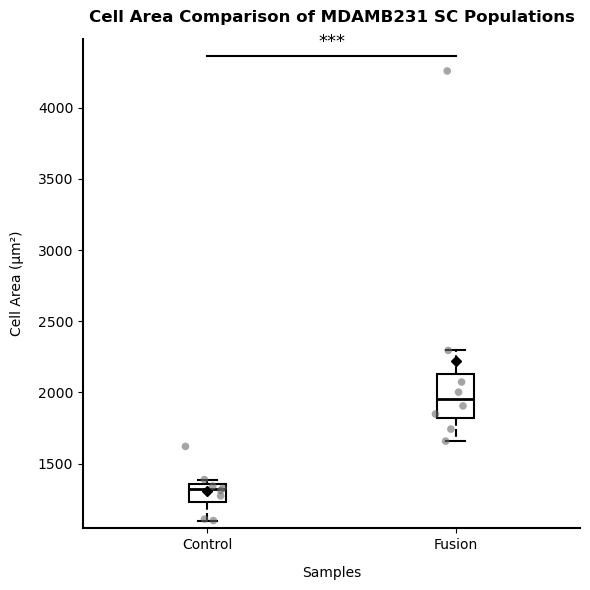

        Control    Fusion
Control     NaN  0.000155
Fusion      NaN       NaN

Averages by Column:
Fusion: 2222.5947232691924
Control: 1309.2391410045468
Parental: 1306.883554850228


In [5]:
cell_area_231 = extract_measurement_by_sample(
    folder_path="/stor/work/Brock/kennedy/SC_repo/data/Morphology/MDA-MB-231_Morphology/231_sc_cell",
    measurement_col="area_um2"
)
cell_area_231_grouped = summarize_samples_to_groups(cell_area_231)
print(cell_area_231_grouped)

cell_area_p_231 = stats_and_plot(cell_area_231_grouped[['Control','Fusion']], alpha=0.05, sig_bars=True, point_label=False, ylabel='Cell Area (μm²)', fig_size=(6, 6), font_sz=24, title='Cell Area Comparison of MDAMB231 SC Populations',save_svg=True)

print(cell_area_p_231)
print("\nAverages by Column:")
for column in cell_area_231_grouped.columns:
    average = cell_area_231_grouped[column].mean()
    print(f"{column}: {average}")

### 231 Nuclear Area

         Fusion     Control    Parental
C1          NaN  505.931363         NaN
C2          NaN  486.209163         NaN
C3          NaN  502.439992         NaN
C4          NaN  478.525074         NaN
C5          NaN  549.097401         NaN
C6          NaN  534.973220         NaN
C7          NaN  436.103948         NaN
C8          NaN  457.052172         NaN
F1   500.386626         NaN         NaN
F2   687.958738         NaN         NaN
F3   587.502480         NaN         NaN
F4   550.425288         NaN         NaN
F5   597.024400         NaN         NaN
F6   606.705019         NaN         NaN
F7   652.251537         NaN         NaN
F8   583.376314         NaN         NaN
GFP         NaN         NaN  569.252133
MC          NaN         NaN  544.336441
Normality (Shapiro-Wilk):     PASS
Equal variance (Levene's):    PASS
Test selected:                Independent samples t-test
p-value:                      0.0009


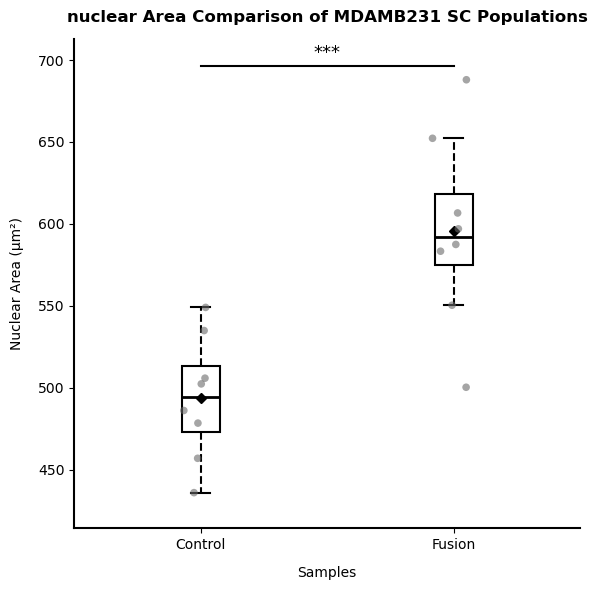

        Control    Fusion
Control     NaN  0.000908
Fusion      NaN       NaN

Averages by Column:
Fusion: 595.7038002663869
Control: 493.79154161168526
Parental: 556.7942868478475


In [6]:
nuclear_area_231 = extract_measurement_by_sample(
    folder_path="/stor/work/Brock/kennedy/SC_repo/data/Morphology/MDA-MB-231_Morphology/231_sc_nuclear",
    measurement_col="area_um2"
)
nuclear_area_231_grouped = summarize_samples_to_groups(nuclear_area_231)
print(nuclear_area_231_grouped)

nuclear_area_p_231 = stats_and_plot(nuclear_area_231_grouped[['Control','Fusion']], alpha=0.05, sig_bars=True, font_sz=24, point_label=False, ylabel='Nuclear Area (μm²)', fig_size=(6, 6), title='nuclear Area Comparison of MDAMB231 SC Populations',save_svg=True)

print(nuclear_area_p_231)
print("\nAverages by Column:")
for column in nuclear_area_231_grouped.columns:
    average = nuclear_area_231_grouped[column].mean()
    print(f"{column}: {average}")

### 231 Nuclear to Cytoplasmic Ratio

       Fusion   Control  Parental
C1        NaN  0.420511       NaN
C2        NaN  0.332231       NaN
C3        NaN  0.402456       NaN
C4        NaN  0.380008       NaN
C5        NaN  0.429725       NaN
C6        NaN  0.398731       NaN
C7        NaN  0.414035       NaN
C8        NaN  0.438125       NaN
F1   0.310905       NaN       NaN
F2   0.214267       NaN       NaN
F3   0.330615       NaN       NaN
F4   0.357577       NaN       NaN
F5   0.331849       NaN       NaN
F6   0.311790       NaN       NaN
F7   0.299854       NaN       NaN
F8   0.358954       NaN       NaN
GFP       NaN       NaN  0.427479
MC        NaN       NaN  0.457871
Normality (Shapiro-Wilk):     PASS
Equal variance (Levene's):    PASS
Test selected:                Independent samples t-test
p-value:                      0.0007


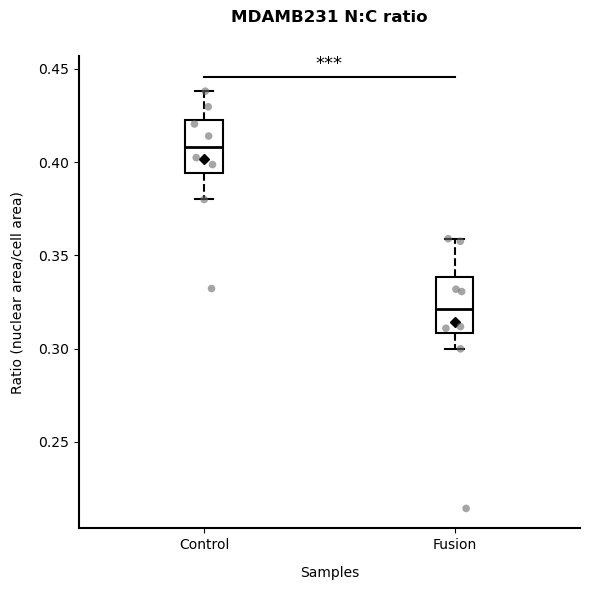

        Control    Fusion
Control     NaN  0.000658
Fusion      NaN       NaN

Averages by Column:
Fusion: 0.3144764168744801
Control: 0.40197771207238936
Parental: 0.4426746999503477


In [7]:
nuc_cyto_ratio_231 = nuclear_area_231/cell_area_231
nuc_cyto_ratio_231_grouped = summarize_samples_to_groups(nuc_cyto_ratio_231)
print(nuc_cyto_ratio_231_grouped)

nuc_cyto_ratio_p_231 = stats_and_plot(nuc_cyto_ratio_231_grouped[['Control','Fusion']], alpha=0.05, sig_bars=True, font_sz=24, ylabel='Ratio (nuclear area/cell area)', fig_size=(6, 6), title='MDAMB231 N:C ratio\n ',save_svg=True)
print(nuc_cyto_ratio_p_231)
print("\nAverages by Column:")
for column in nuc_cyto_ratio_231_grouped.columns:
    average = nuc_cyto_ratio_231_grouped[column].mean()
    print(f"{column}: {average}")